In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,RandomizedSearchCV
from sklearn.linear_model import LinearRegression,LogisticRegression,RidgeCV,LassoCV,ElasticNetCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,classification_report,confusion_matrix,accuracy_score
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier
from sklearn.svm import SVC,SVR

In [3]:
df_iris=pd.read_csv('../sources/Iris.csv')

In [4]:
df_iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df_iris.drop('Id',axis=1,inplace=True)

In [6]:
label_encoder=LabelEncoder()
df_iris['Species']=label_encoder.fit_transform(df_iris['Species'])
df_iris.head(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [7]:
X=df_iris.drop('Species',axis=1)
y=df_iris['Species']

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [9]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

mean absolute error: 0.15722608545760466
mean squared error: 0.041732433198802814
r2 score: 0.9339236474352288


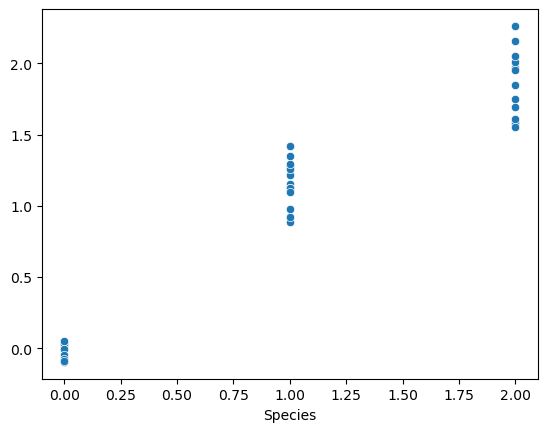

In [10]:
linear=LinearRegression()
linear.fit(X_train_scaled,y_train)
y_pred=linear.predict(X_test_scaled)
msa=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("mean absolute error:",msa)
print("mean squared error:",mse)
print("r2 score:",r2)
sns.scatterplot(x=y_test,y=y_pred)
plt.show()

In [18]:
param_grid={'C':[0.1,1,10,100,1000],
            'kernel':['rbf','linear','poly'],
            'gamma':['scale','auto',0.01,0.1,1,10,100,1000],
            #'penalty':['l1','l2','elasticnet'],
           # 'solver':['lbfgs','liblinear','newton-cg','newton-cholesky','saga','sag']
           } 
import warnings
warnings.filterwarnings('ignore')
grid=GridSearchCV(estimator=SVC(),param_grid=param_grid,cv=5)
grid.fit(X_train_scaled,y_train)
y_pred_grid=grid.predict(X_test_scaled)
print('accurary:',accuracy_score(y_pred_grid,y_test))
print('class:\n',classification_report(y_pred_grid,y_test))
print('confuction',confusion_matrix(y_pred_grid,y_test))

accurary: 1.0
class:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

confuction [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]


In [12]:
grid.best_score_

np.float64(0.9640316205533598)

In [13]:
grid.best_params_

{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

In [14]:
param={'C':[0.1,1,10,100,1000],
            'penalty':['l1','l2','elasticnet'],
            'solver':['lbfgs','liblinear','newton-cg','newton-cholesky','saga','sag']
           } 

In [19]:
model=LogisticRegression()

In [21]:
grid_log=GridSearchCV(param_grid=param,estimator=model,cv=5)
grid_log.fit(X_train_scaled,y_train)
y_pred_log=grid_log.predict(X_test_scaled)
print('accurary:',accuracy_score(y_pred_log,y_test))
print('class:\n',classification_report(y_pred_log,y_test))
print('confuction',confusion_matrix(y_pred_log,y_test))

accurary: 1.0
class:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

confuction [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
